## Resources

### Introduction to Random Forest

Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during training. For classification tasks, the output of the random forest is the class selected by most trees. For regression tasks, the mean or average prediction of the individual trees is used. It addresses the problem of overfitting in decision trees and improves accuracy.

### Ensemble Learning

Ensemble learning is a general meta-approach to machine learning that seeks to improve model performance by combining predictions from multiple models, rather than using a single model. The core idea is that a group of weak learners can form a strong learner. Random Forest is a prominent example of an ensemble method, specifically using a technique called 'bagging' (Bootstrap Aggregating).

### Bootstrap Sampling

Bootstrap sampling is a resampling technique used to create multiple subsets of the original dataset. In the context of Random Forest, for each decision tree in the forest, a new training dataset is created by randomly sampling, with replacement, from the original dataset. This means some data points may appear multiple times in a bootstrap sample, while others may not appear at all. This randomness helps to decorrelate the trees.

### Feature Bagging (Random Subspace Method)

In addition to bootstrap sampling the data, Random Forest also introduces randomness by selecting a random subset of features (or variables) at each split point in the construction of each decision tree. This is known as feature bagging or the Random Subspace Method. Instead of considering all features to find the best split, only a randomly chosen subset of features is considered. This further decorrelates the individual trees and makes the forest more robust against overfitting.

### Regression vs. Classification

*   **Classification:** When using Random Forest for classification, the goal is to predict a categorical outcome (e.g., 'yes'/'no', 'spam'/'not spam', different species of flowers). Each tree in the forest predicts a class, and the final prediction is determined by majority vote among the trees.
*   **Regression:** When using Random Forest for regression, the goal is to predict a continuous numerical outcome (e.g., house prices, temperature, stock values). Each tree in the forest predicts a numerical value, and the final prediction is typically the average of the predictions from all trees.

### Hyperparameters

Hyperparameters are parameters whose values are set before the learning process begins. They control the learning process itself. For Random Forest, key hyperparameters include:

*   **`n_estimators`**: The number of trees in the forest. A higher number generally leads to better performance but also increases computation time.
*   **`max_features`**: The number of features to consider when looking for the best split. This relates to feature bagging.
*   **`max_depth`**: The maximum depth of the tree. Limiting depth can help prevent overfitting.
*   **`min_samples_split`**: The minimum number of samples required to split an internal node.
*   **`min_samples_leaf`**: The minimum number of samples required to be at a leaf node.

These hyperparameters need to be tuned to optimize the model's performance on unseen data, often through techniques like cross-validation and grid search.

### Feature Importance

Random Forests can provide a measure of feature importance. During the training process, the model tracks how much each feature contributes to reducing impurity (e.g., Gini impurity for classification, mean squared error for regression) across all the trees in the forest. Features that consistently lead to greater reductions in impurity are considered more important. This is a valuable tool for understanding your data and for feature selection.

### Advantages & Disadvantages

**Advantages:**
*   **High Accuracy:** Often performs very well on a wide range of tasks and datasets.
*   **Reduces Overfitting:** The ensemble nature, bootstrap sampling, and feature bagging help to mitigate overfitting, which is a common problem with individual decision trees.
*   **Handles High Dimensionality:** Can work effectively with a large number of features.
*   **Handles Missing Values:** Can be adapted to work well with missing data (though typically imputation is performed beforehand).
*   **Provides Feature Importance:** Offers insights into which features are most influential.
*   **Parallelizable:** The construction of individual trees can be parallelized, making it efficient for large datasets.

**Disadvantages:**
*   **Less Interpretability:** While feature importance is available, the overall model is a 'black box' compared to a single decision tree, making it harder to understand the exact decision-making process.
*   **Computationally Intensive:** Training many trees can be computationally expensive and time-consuming, especially with a large number of trees and/or features.
*   **Memory Intensive:** Storing many trees can consume a significant amount of memory.
*   **Might Not Perform Well on Small Datasets:** For very small datasets, the benefits of ensemble learning might not be fully realized.

### Evaluation Metrics

The choice of evaluation metrics depends on whether you're performing a classification or regression task.

**For Classification:**
*   **Accuracy:** The proportion of correctly classified instances.
*   **Precision:** The proportion of positive identifications that were actually correct.
*   **Recall (Sensitivity):** The proportion of actual positives that were identified correctly.
*   **F1-Score:** The harmonic mean of precision and recall.
*   **ROC AUC:** Receiver Operating Characteristic Area Under the Curve, which measures the trade-off between the true positive rate and the false positive rate.
*   **Confusion Matrix:** A table summarizing the number of correct and incorrect predictions for each class.

**For Regression:**
*   **Mean Squared Error (MSE):** The average of the squared differences between predicted and actual values.
*   **Root Mean Squared Error (RMSE):** The square root of the MSE, providing a metric in the same units as the target variable.
*   **Mean Absolute Error (MAE):** The average of the absolute differences between predicted and actual values.
*   **R-squared (Coefficient of Determination):** Represents the proportion of variance in the dependent variable that can be predicted from the independent variables.

## Random Forest Implementation Example

This example demonstrates how to implement a Random Forest for both classification and regression tasks using the `scikit-learn` library. We will generate synthetic datasets for both scenarios.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Random Forest for Classification

First, we'll create a synthetic dataset for a classification problem, split it into training and testing sets, train a `RandomForestClassifier`, and evaluate its performance.

Random Forest Classifier Accuracy: 0.9300


/tmp/ipykernel_397/4142836023.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_cls.index, y=feature_importances_cls.values, palette='viridis')


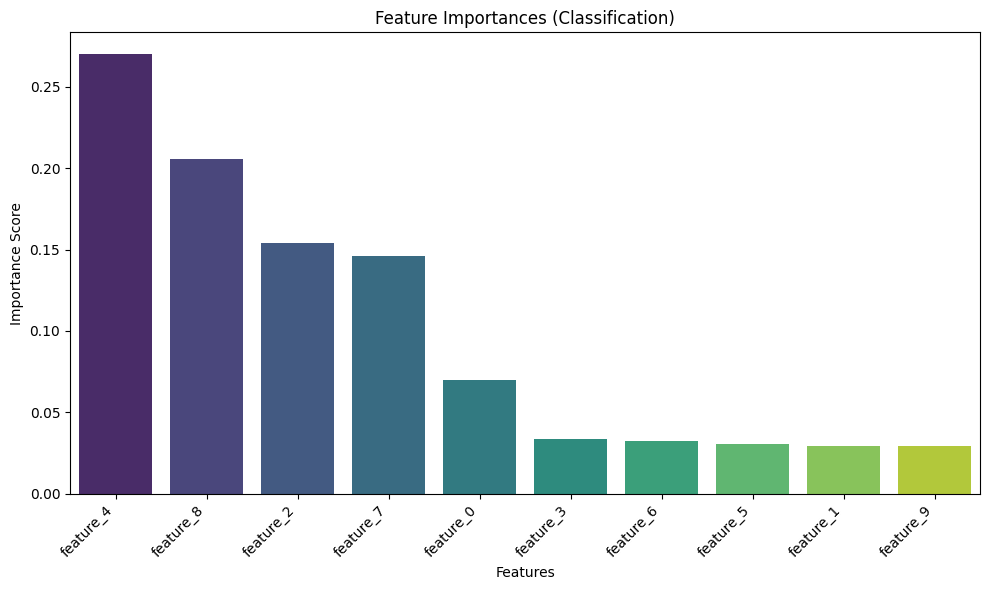

In [2]:
# Generate synthetic data for classification
from sklearn.datasets import make_classification
X_cls, y_cls = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=0, random_state=42)

# Split data into training and testing sets
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.3, random_state=42)

# Initialize and train the Random Forest Classifier
# n_estimators: number of trees in the forest
# random_state: for reproducibility
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_classifier.fit(X_train_cls, y_train_cls)

# Make predictions
y_pred_cls = rf_classifier.predict(X_test_cls)

# Evaluate the classifier
accuracy = accuracy_score(y_test_cls, y_pred_cls)
print(f"Random Forest Classifier Accuracy: {accuracy:.4f}")

# Display feature importances for classification
feature_importances_cls = pd.Series(rf_classifier.feature_importances_, index=[f'feature_{i}' for i in range(X_cls.shape[1])])
feature_importances_cls.sort_values(ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_cls.index, y=feature_importances_cls.values, palette='viridis')
plt.title('Feature Importances (Classification)')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Random Forest for Regression

Next, we'll create a synthetic dataset for a regression problem, split it, train a `RandomForestRegressor`, and evaluate its performance.

Random Forest Regressor Mean Squared Error: 209.3406
Random Forest Regressor Root Mean Squared Error: 14.4686


/tmp/ipykernel_397/66169136.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_reg.index, y=feature_importances_reg.values, palette='mako')


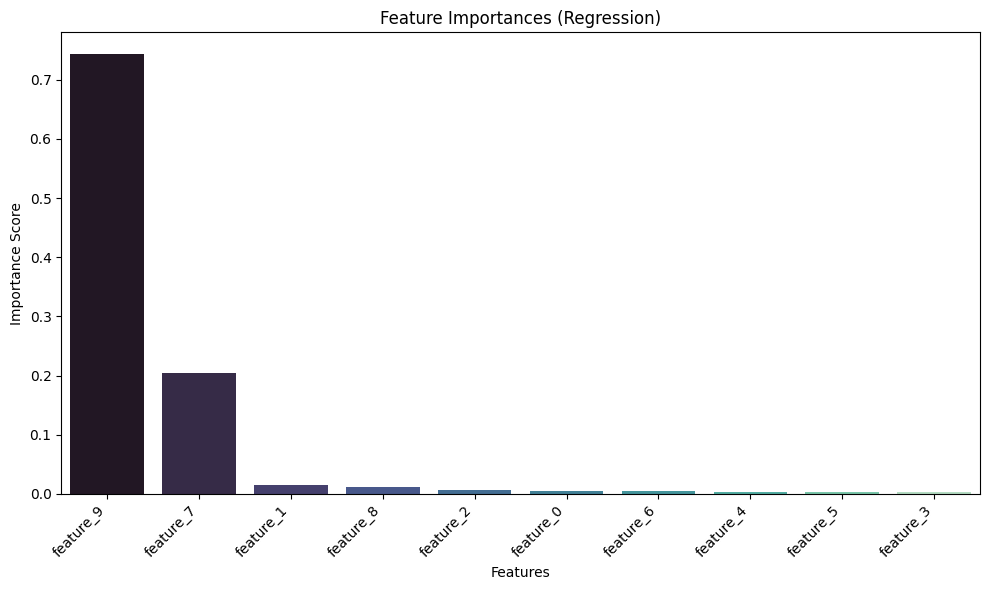

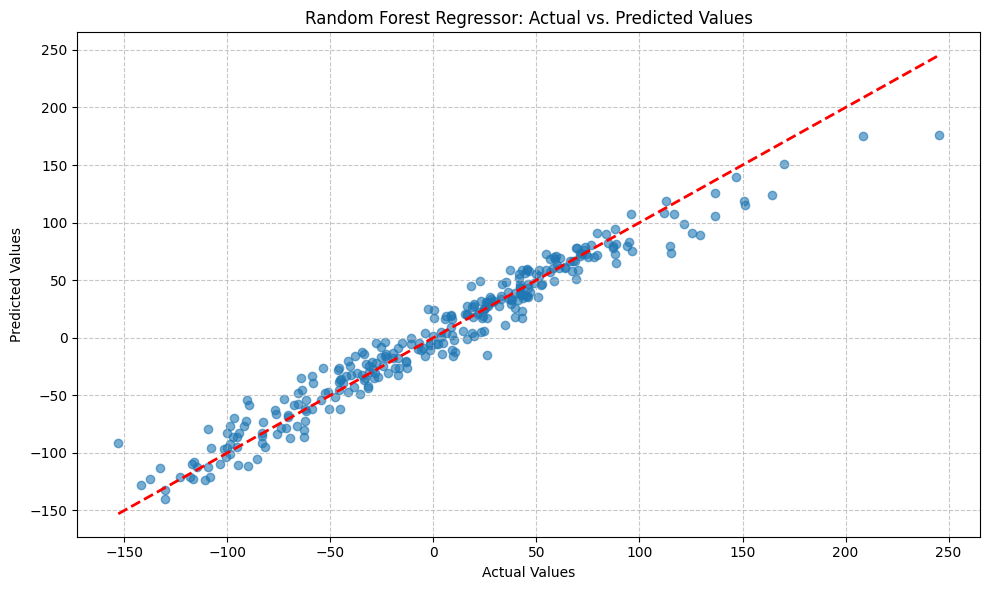

In [3]:
# Generate synthetic data for regression
from sklearn.datasets import make_regression
X_reg, y_reg = make_regression(n_samples=1000, n_features=10, n_informative=5, random_state=42)

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Initialize and train the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_reg = rf_regressor.predict(X_test_reg)

# Evaluate the regressor
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
print(f"Random Forest Regressor Mean Squared Error: {mse:.4f}")
print(f"Random Forest Regressor Root Mean Squared Error: {rmse:.4f}")

# Display feature importances for regression
feature_importances_reg = pd.Series(rf_regressor.feature_importances_, index=[f'feature_{i}' for i in range(X_reg.shape[1])])
feature_importances_reg.sort_values(ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_reg.index, y=feature_importances_reg.values, palette='mako')
plt.title('Feature Importances (Regression)')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot actual vs. predicted values for regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Random Forest Regressor: Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Program 1: Iris Flower Classification (Random Forest Classifier)

In [40]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
iris = load_iris()

X=iris.data
y=iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Sample Prediction
sample = [[5.1,3.5,1.4,0.2]]
prediction = model.predict(sample)


Accuracy: 1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



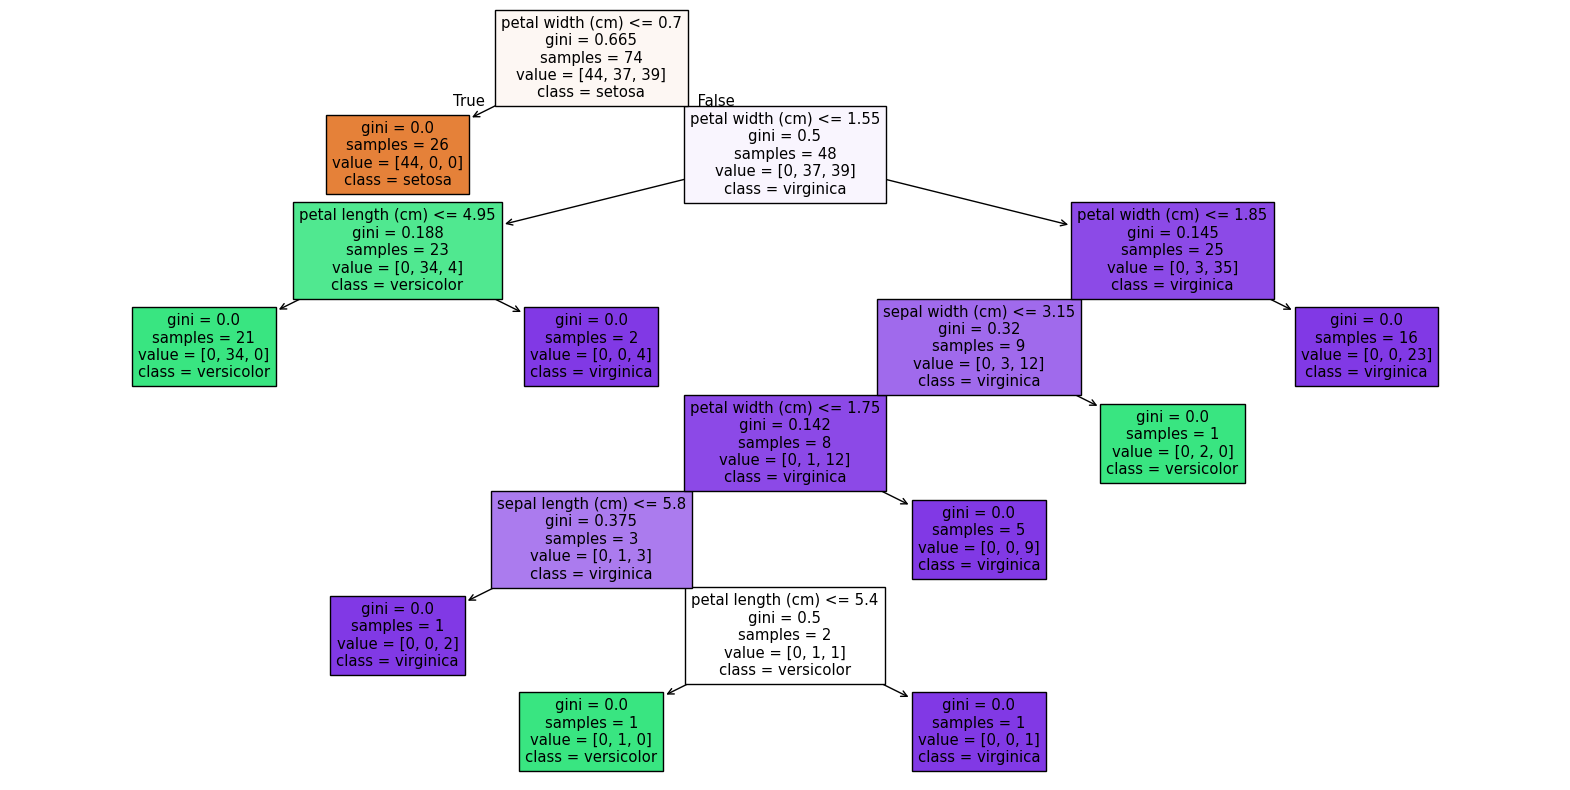

In [43]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model.estimators_[0],
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)

plt.show()

In [44]:
print(len(model.estimators_))

100


In [45]:
tree = model.estimators_[0]
print(tree)

DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)


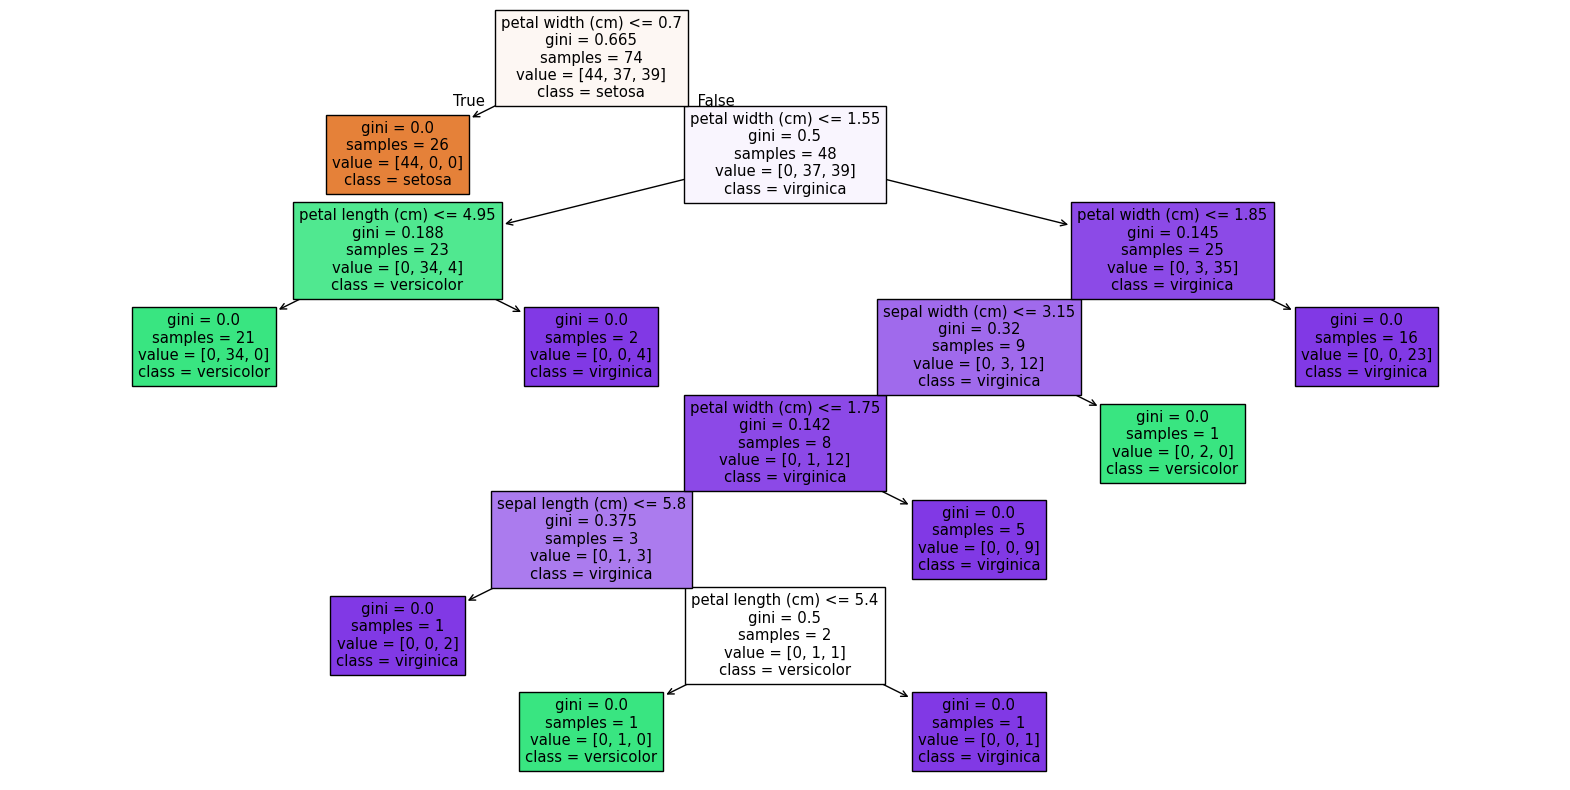

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    model.estimators_[0],
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)
plt.show()

# Program 2: Wine Quality Classification

In [7]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [8]:
wine=load_wine()
X=wine.data
y=wine.target

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model=RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [13]:

prediction = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test,prediction))

print("\nFeature Importance")

for feature,importance in zip(wine.feature_names,
                              model.feature_importances_):
    print(feature,":",round(importance,3))

Accuracy : 1.0

Feature Importance
alcohol : 0.112
malic_acid : 0.036
ash : 0.021
alcalinity_of_ash : 0.032
magnesium : 0.037
total_phenols : 0.029
flavanoids : 0.202
nonflavanoid_phenols : 0.014
proanthocyanins : 0.024
color_intensity : 0.171
hue : 0.071
od280/od315_of_diluted_wines : 0.112
proline : 0.139


# Program 3: Breast Cancer Prediction

In [14]:
from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report

In [15]:
data=load_breast_cancer()
X=data.data
y=data.target

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model=RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [38]:
print(len(model.estimators_))

200


In [18]:
prediction=model.predict(X_test)

print(classification_report(y_test,prediction))

print("Accuracy :",model.score(X_test,y_test))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Accuracy : 0.9649122807017544


# Program 4 :Employee Attrition Prediction (Classification)

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [20]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.head())

print(df.shape)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [22]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [23]:
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

In [24]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [34]:
import numpy as np

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

In [36]:
print("Numerical Columns:")
print(num_cols)
print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Categorical Columns:
Index([], dtype='object')


In [25]:
# Label Encoding
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])


In [26]:
# Features and Target
X = df.drop("Attrition",axis=1)

y = df["Attrition"]


In [27]:
# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42
)

In [28]:
# Model
model = RandomForestClassifier(

    n_estimators=200,

    random_state=42
)


In [29]:
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [37]:
print(len(model.estimators_))

200


In [30]:
prediction = model.predict(X_test)

In [31]:
# Accuracy
print("Accuracy :",accuracy_score(y_test,prediction))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test,prediction))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test,prediction))

Accuracy : 0.8741496598639455

Confusion Matrix
[[253   2]
 [ 35   4]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294



In [32]:

# Feature Importance
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)

print("\nTop Important Features")
print(importance.head(10))


Top Important Features
              Feature  Importance
17      MonthlyIncome    0.074145
21           OverTime    0.064174
0                 Age    0.058181
2           DailyRate    0.050863
27  TotalWorkingYears    0.049297
8      EmployeeNumber    0.047671
18        MonthlyRate    0.045375
11         HourlyRate    0.043815
4    DistanceFromHome    0.043084
30     YearsAtCompany    0.042466
